# 감성대화 말뭉치 EDA — 웰니스 챗봇 감정분류
> **작성**: 김한솔 · 2026-07-03
> **데이터**: AI Hub 감성대화 말뭉치 정제본 `data/kcelectra_train_clean.jsonl`
> **목적**: 감정 라우팅(4모드) 학습 데이터의 품질·구성 확인과 정제/설계 결정의 근거 제시

## 목차
1. 기본 정보 확인
2. 결측치 확인
3. 중복 확인
4. 라벨 분포 EDA (6감정 → 4모드)
5. 이상치 확인
6. 최빈 단어 분석 — 데이터에 뭐가 있나
7. 정제 결정 요약 — "~한 이유에서 이것만 남겼다"
8. (심화) 감정 신호 토큰 / 모델 선정\n9. (심화) 원천 메타데이터 — 연령·상황·세부감정·분할 검증\n10. 한계와 서비스 보완

## 0. 데이터 출처와 구축 방식 (AI Hub 감성대화 말뭉치)

> 근거: 『인공지능 데이터 구축·활용 가이드라인 — 감성 대화 말뭉치』 (미디어젠, Ver 1.4, 2020-12-23)

| 항목 | 내용 |
|---|---|
| **구축 목적** | 감성 챗봇용 세대별 감성대화 텍스트 (NLU 모델링용) |
| **수집 방식** | 크라우드 워커가 주어진 상황에 맞춰 **직접 작성** (크롤링 아님 → 저작권 청정, 구어체 보장) |
| **원시 규모** | 약 27만 문장 |
| **감정 체계** | **6 대분류**(분노·슬픔·불안·상처·당황·기쁨) × 세부 10종 = 60 감정 |
| **페르소나** | 연령(청소년/청년/중년/노년) × 성별, 상황(S)·질병(D)·감정(E) 요인 |
| **대화 구조** | 3~4턴 (사람 발화 ↔ 시스템 호응 응답), JSON 저장 |
| **품질 관리** | 정제 담당자·상용 근로자·전문가 3단 검수 |

**우리 정제본과의 관계**: `kcelectra_train_clean.jsonl`은 이 말뭉치에서 **첫 사람 발화(HS01)의 텍스트와
6 대분류 라벨(E코드 첫째 자리)만 취한 것** — §0-2에서 원천 대비 100% 일치로 검증했다.
세부 60감정·페르소나·시스템 응답은 제외: 챗봇 톤 라우팅에는 대분류로 충분하고(4모드로 재매핑, §4-2),
시스템 응답은 우리가 LLM으로 생성하기 때문.

**주목할 점**: 원 말뭉치 자체가 "사람의 감정 발화 ↔ 시스템의 호응 응답" 구조로 설계된 데이터다.
즉 이 데이터의 설계 목적(감성 챗봇)과 우리 서비스가 정확히 같은 지점에 있다 — 도메인 정합성의 근거.

In [1]:
import json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter

for f in fm.fontManager.ttflist:
    if 'Nanum' in f.name or 'CJK' in f.name:
        plt.rcParams['font.family'] = f.name
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_colwidth', 80)

rows = [json.loads(l) for l in open('../../data/kcelectra_train_clean.jsonl', encoding='utf-8') if l.strip()]
df = pd.DataFrame(rows)
print('로드 완료:', df.shape)

로드 완료: (58234, 2)


## 0-2. 원천 대비 정제 계보 검증

원천(AI Hub 라벨링데이터 JSON: Training 51,628 + Validation 6,640 = **58,268 대화**)과
정제본 58,234건을 직접 대조해 정제 과정을 역추적한다.
(원천 데이터가 로컬에 없으면 이 셀은 자동 스킵)

In [2]:
import os, re
RAW_CANDIDATES = [
    r'C:\Users\Playdata\Documents\Obsidian Vault\SKN27기 최종프로젝트 - 웰니스 멘탈케어\데이터\감성대화\018.감성대화',
    '/sessions/epic-friendly-knuth/mnt/SKN27기 최종프로젝트 - 웰니스 멘탈케어/데이터/감성대화/018.감성대화',
]
RAW = next((p for p in RAW_CANDIDATES if os.path.isdir(p)), None)

if RAW is None:
    print('원천 데이터 없음 — 검증 스킵 (결과는 아래 마크다운 참조)')
else:
    norm = lambda s: re.sub(r'\s+', ' ', s.replace('\xa0', ' ')).strip()
    E2NAME = {'1':'분노','2':'슬픔','3':'불안','4':'상처','5':'당황','6':'기쁨'}
    tr = json.load(open(os.path.join(RAW, 'Training_221115_add/라벨링데이터/_ext/감성대화말뭉치(최종데이터)_Training.json'), encoding='utf-8'))
    va = json.load(open(os.path.join(RAW, 'Validation_221115_add/라벨링데이터/_ext/감성대화말뭉치(최종데이터)_Validation.json'), encoding='utf-8'))
    pairs = [(norm(d['talk']['content'].get('HS01') or ''), E2NAME.get(d['profile']['emotion']['type'][1], '?')) for d in tr + va]
    src_set = set(pairs)
    clean_set = {(norm(t), e) for t, e in zip(df['text'], df['emotion'])}

    print(f'원천 대화: {len(pairs):,} (Training {len(tr):,} + Validation {len(va):,})')
    print(f'  → 완전 중복(문장+라벨) 제거: {len(pairs) - len(src_set)}건 → 고유 {len(src_set):,}')
    print(f'정제본: {len(clean_set):,}')
    print(f'일치: {len(clean_set & src_set):,}건 = 정제본의 {len(clean_set & src_set)/len(clean_set)*100:.3f}%')
    conflict = src_set - clean_set
    print(f'원천 고유 조합 중 추가 탈락: {len(conflict)}건')
    resolved = sum(1 for t, e in conflict if any((t, e2) in clean_set for e2 in E2NAME.values()))
    print(f'  그중 같은 문장이 다른 라벨로 정제본에 존재(=라벨 상충 단일화): {resolved}건')

원천 대화: 58,268 (Training 51,628 + Validation 6,640)
  → 완전 중복(문장+라벨) 제거: 17건 → 고유 58,251
정제본: 58,234
일치: 58,234건 = 정제본의 100.000%
원천 고유 조합 중 추가 탈락: 17건
  그중 같은 문장이 다른 라벨로 정제본에 존재(=라벨 상충 단일화): 17건


## 1. 기본 정보 확인

In [3]:
print(f'행 × 열: {df.shape[0]:,} × {df.shape[1]}')
df.info()
df['length'] = df['text'].str.len()
display(df.head(5))
df[['length']].describe().T.round(1)

행 × 열: 58,234 × 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58234 entries, 0 to 58233
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     58234 non-null  object
 1   emotion  58234 non-null  object
dtypes: object(2)
memory usage: 910.0+ KB


,text,emotion,length
0,일은 왜 해도 해도 끝이 없을까? 화가 난다.,분노,25
1,이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나.,분노,46
2,회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스트레스 받아.,분노,53
3,직장에서 막내라는 이유로 나에게만 온갖 심부름을 시켜. 일도 많은 데 정말 분하고 섭섭해.,분노,50
4,얼마 전 입사한 신입사원이 나를 무시하는 것 같아서 너무 화가 나.,분노,37


,count,mean,std,min,25%,50%,75%,max
length,58234.0,35.3,11.9,5.0,27.0,35.0,44.0,156.0


## 2. 결측치 확인

NaN뿐 아니라 **빈 문자열·공백만 있는 문장**도 실질 결측으로 함께 확인한다.

In [4]:
nan_cnt = df['text'].isna().sum()
empty_cnt = (df['text'].fillna('').str.strip() == '').sum()
label_nan = df['emotion'].isna().sum()
print(f'text NaN: {nan_cnt}건 / 빈·공백 문장: {empty_cnt}건 / emotion NaN: {label_nan}건')
assert nan_cnt == empty_cnt == label_nan == 0, '결측 존재 — 정제 필요'
print('→ 결측 없음 (정제본이므로 원천 단계에서 이미 제거됨)')

text NaN: 0건 / 빈·공백 문장: 0건 / emotion NaN: 0건
→ 결측 없음 (정제본이므로 원천 단계에서 이미 제거됨)


## 3. 중복 확인

완전 중복(문장+라벨)과 문장만 중복(라벨 상충 가능)을 구분해서 본다. 라벨 상충 중복은 학습에 노이즈가 되므로 특히 중요.

In [5]:
dup_full = df.duplicated(subset=['text','emotion']).sum()
dup_text = df.duplicated(subset=['text']).sum()
conflict = dup_text - dup_full   # 같은 문장인데 라벨이 다른 경우
print(f'완전 중복(문장+라벨): {dup_full:,}건 / 문장만 중복: {dup_text:,}건 / 그중 라벨 상충: {conflict:,}건')
if dup_text:
    display(df[df.duplicated(subset=['text'], keep=False)].sort_values('text').head(6))
print(f'중복 비율: {dup_text/len(df)*100:.2f}% → 전체의 1% 미만이면 학습 영향 미미')

완전 중복(문장+라벨): 0건 / 문장만 중복: 0건 / 그중 라벨 상충: 0건
중복 비율: 0.00% → 전체의 1% 미만이면 학습 영향 미미


## 4. 라벨 분포 EDA

### 4-1. 원천 6감정 분포

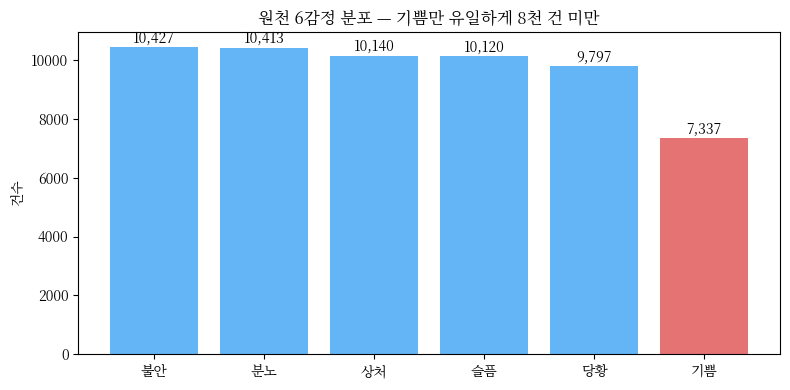

emotion
불안    17.9%
분노    17.9%
상처    17.4%
슬픔    17.4%
당황    16.8%
기쁨    12.6%
Name: count, dtype: object


In [6]:
order6 = df['emotion'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E57373' if v == order6.min() else '#64B5F6' for v in order6.values]
ax.bar(order6.index, order6.values, color=colors)
for i, v in enumerate(order6.values):
    ax.text(i, v + 150, f'{v:,}', ha='center', fontsize=10)
ax.set_title('원천 6감정 분포 — 기쁨만 유일하게 8천 건 미만')
ax.set_ylabel('건수'); plt.tight_layout(); plt.show()
print((order6 / len(df) * 100).round(1).astype(str) + '%')

### 4-2. 6감정 → 4모드 매핑 후 분포

서비스 응답 톤은 4모드(기쁨/슬픔/분노/일반)로 운영한다. 클래스를 줄인 이유:
친구 컨셉에서 불안·상처·당황의 응답 스타일 차이가 모호하고, 클래스가 늘수록 정확도가 떨어져
**틀린 톤으로 공감하는 최악의 UX** 위험이 커지기 때문.

| 원천 | 4모드 | 근거 |
|---|---|---|
| 기쁨 | 기쁨 | 그대로 |
| 슬픔, 상처 | 슬픔 | 위로가 필요한 감정 |
| 분노, 불안 | 분노 | 편들기·안정화가 필요한 격앙 상태 |
| 당황 | 일반 | 가벼운 리액션으로 충분 |

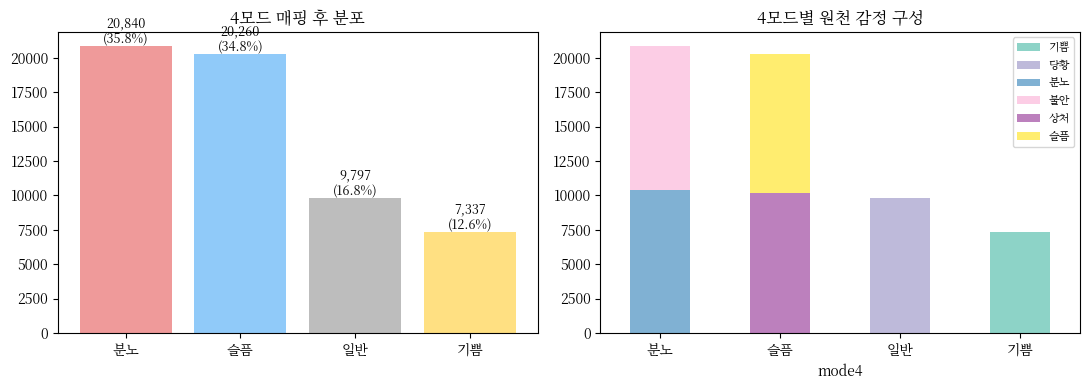

클래스 불균형 2.8배 (분노 20,840 vs 기쁨 7,337) → 학습 시 클래스 가중치 w=N/(K·freq)로 보정


In [7]:
six_to_four = {'기쁨':'기쁨','슬픔':'슬픔','상처':'슬픔','분노':'분노','불안':'분노','당황':'일반'}
df['mode4'] = df['emotion'].map(six_to_four)
order4 = df['mode4'].value_counts().reindex(['분노','슬픔','일반','기쁨'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(order4.index, order4.values, color=['#EF9A9A','#90CAF9','#BDBDBD','#FFE082'])
for i, v in enumerate(order4.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
axes[0].set_title('4모드 매핑 후 분포')
comp = df.groupby(['mode4','emotion']).size().unstack(fill_value=0).reindex(['분노','슬픔','일반','기쁨'])
comp.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3', rot=0)
axes[1].set_title('4모드별 원천 감정 구성'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
imb = order4.max()/order4.min()
print(f'클래스 불균형 {imb:.1f}배 (분노 {order4.max():,} vs 기쁨 {order4.min():,}) → 학습 시 클래스 가중치 w=N/(K·freq)로 보정')

## 5. 이상치 확인

길이 기준(IQR)·초단문·한글 비율로 세 가지 관점에서 확인하고, 실제 사례를 눈으로 검증한다.

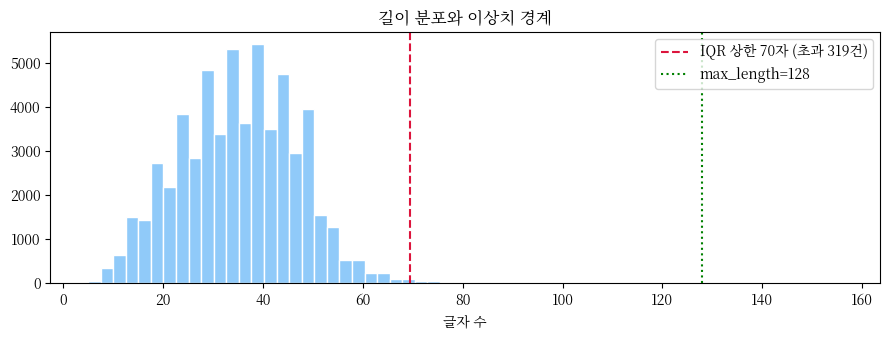

장문 이상치(> 70자): 319건 (0.55%) / 최장 156자
초단문(< 5자): 0건 / 한글 비율 30% 미만: 0건
128자 초과(토크나이저 절단 대상): 2건 (0.00%)

[최장문 예시] 아 결국 친구한테 빌려준 돈을 못 받게 생겼어. 급전이 필요하다고 부탁해서 여러차례 빌려준게 벌써 천 만원이 넘는데 십 년이 지나도 갚을 생각을 안하는것 같아 연락을 했더니 전화번 …


In [8]:
q1, q3 = df['length'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
too_long = df[df['length'] > upper]
too_short = df[df['length'] < 5]
df['hangul_ratio'] = df['text'].apply(lambda t: len(re.findall(r'[가-힣]', t)) / max(len(t), 1))
low_hangul = df[df['hangul_ratio'] < 0.3]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(df['length'], bins=60, color='#90CAF9', edgecolor='white')
ax.axvline(upper, color='crimson', ls='--', label=f'IQR 상한 {upper:.0f}자 (초과 {len(too_long):,}건)')
ax.axvline(128, color='green', ls=':', label='max_length=128')
ax.set_title('길이 분포와 이상치 경계'); ax.set_xlabel('글자 수'); ax.legend()
plt.tight_layout(); plt.show()

print(f'장문 이상치(> {upper:.0f}자): {len(too_long):,}건 ({len(too_long)/len(df)*100:.2f}%) / 최장 {df.length.max()}자')
print(f'초단문(< 5자): {len(too_short):,}건 / 한글 비율 30% 미만: {len(low_hangul):,}건')
print(f'128자 초과(토크나이저 절단 대상): {(df.length > 128).sum():,}건 ({(df.length > 128).mean()*100:.2f}%)')
print()
print('[최장문 예시]', df.loc[df.length.idxmax(), 'text'][:100], '…')
if len(too_short): display(too_short.head(5)[['text','emotion']])
if len(low_hangul): display(low_hangul.head(3)[['text','emotion','hangul_ratio']])

**판정**: 장문 이상치도 정상적인 고민 서술문이고 128자 초과가 극소수라 **제거하지 않고 토크나이저 절단으로 처리**.
초단문·비한글 문장이 있다면 감정 신호가 없는 노이즈인지 확인 후 판단한다.

## 6. 최빈 단어 분석 — 데이터에 뭐가 있나

간단 토큰화(한글 2글자 이상 어절)로 감정별 최빈 단어를 본다. 형태소 분석기 없이도 데이터의 주제 영역을 파악하는 게 목적.

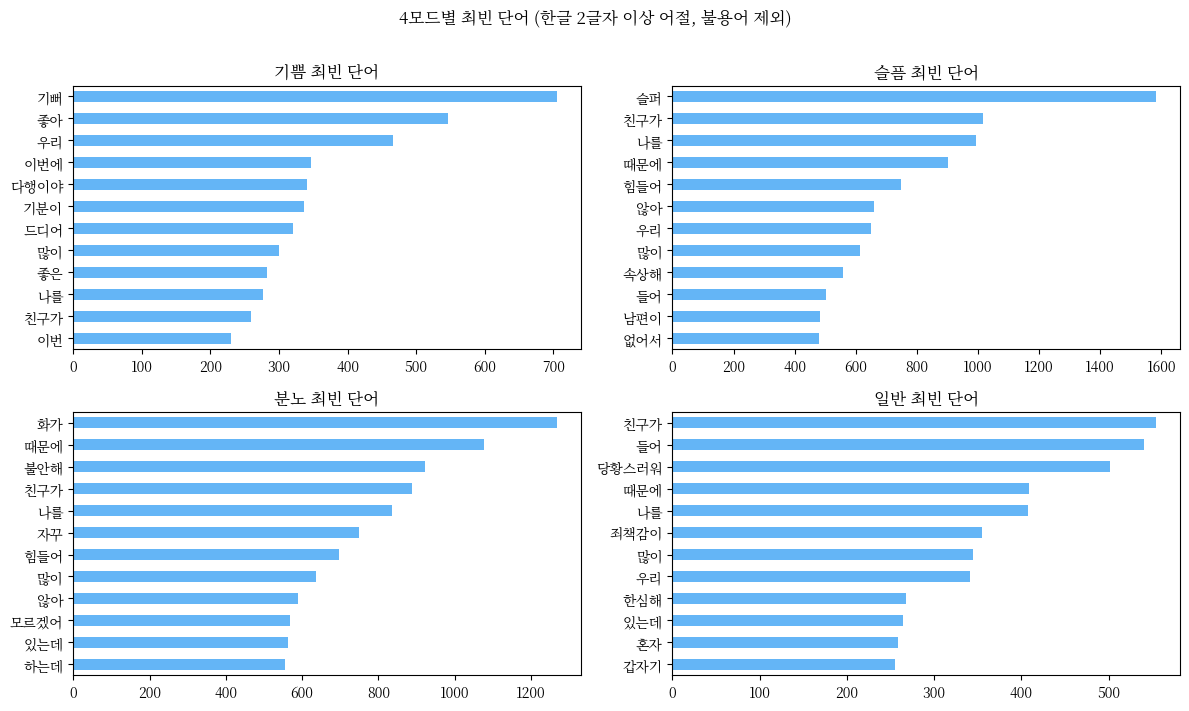

전체 최빈 20: ['친구가', '나를', '때문에', '우리', '많이', '슬퍼', '들어', '힘들어', '않아', '화가', '있는데', '자꾸', '아내가', '남편이', '같아서', '했는데', '일을', '하는데', '없어서', '모르겠어']


In [9]:
STOP = set('그래서 그런데 하지만 그리고 정말 진짜 너무 요즘 오늘 내가 나는 나도 내는 그냥 같아 있어 없어 했어 해서 하는 있는 없는 그게 이게 저게 것 수 게 때 좀 더 잘 안 못 왜 또 다 이 그 저 는 은 이 가 을 를 에 서 도 만 은근 아니 근데 이제 지금 하고 해도 할까 어떻게 어떡하지'.split())
def tokens(s):
    return [w for w in re.findall(r'[가-힣]{2,}', s) if w not in STOP]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, mode in zip(axes.flat, ['기쁨','슬픔','분노','일반']):
    cnt = Counter()
    for t in df.loc[df['mode4'] == mode, 'text']:
        cnt.update(tokens(t))
    top = pd.Series(dict(cnt.most_common(12))).iloc[::-1]
    top.plot(kind='barh', ax=ax, color='#64B5F6')
    ax.set_title(f'{mode} 최빈 단어')
plt.suptitle('4모드별 최빈 단어 (한글 2글자 이상 어절, 불용어 제외)', y=1.01)
plt.tight_layout(); plt.show()

total = Counter()
for t in df['text']: total.update(tokens(t))
print('전체 최빈 20:', [w for w, _ in total.most_common(20)])

**관찰 포인트**: 회사·친구·엄마·남편 같은 **일상 관계어**가 상위권 → 이 말뭉치는 상담체가 아니라
일상 고민 발화라서, '친구에게 털어놓는 말투'인 우리 서비스의 실사용 입력과 도메인이 일치한다.
이것이 이 데이터를 학습원으로 선택한 근거.

## 7. 정제 결정 요약 — "~한 이유에서 이것만 남겼다"

| 결정 | 이유 |
|---|---|
| **HS01(첫 사람 발화)만 추출** | 첫 발화가 "감정 상태 발화"로 설계된 턴(가이드라인 §3.1) — 시스템 응답·후속 턴은 감정 라벨과의 결합이 약함. 원천 58,268 대화 → 100% 계보 일치 검증(§0-2) |
| **세부 60감정 → 6 대분류(E코드 첫자리)** | 톤 라우팅엔 대분류로 충분, 세부 감정은 클래스당 표본이 얇아짐 |
| **공백 정규화(\\xa0·다중 공백)** | 표기 노이즈 제거 — 내용 변형 없음 |
| **ㅋㅋ/ㅠㅠ/!!/반복문자 보존** (`clean_keep_signal`) | §8-1에서 확인: 감정별 출현율이 뚜렷이 갈리는 핵심 신호 — 지우면 정보 손실 |
| **6감정 전량 유지 → 4모드 매핑** | 상처→슬픔, 불안→분노로 흡수해 58,234건 중 한 건도 버리지 않음 |
| **장문 이상치 미제거** | 정상 고민 서술문 + 128자 초과 극소수 → 토크나이저 절단으로 충분 |
| **클래스 가중치 (언더샘플링 X)** | 불균형 보정을 위해 다수 클래스를 버리는 대신 손실 가중치로 처리 — 데이터 전량 활용 |
| **중복 검증 통과** | 완전 중복·라벨 상충 모두 0건(§3) — 정제본 품질 확인, 추가 제거 불필요 |

## 8. (심화) 감정 신호 토큰 — 전처리 설계의 데이터 근거

/sessions/epic-friendly-knuth/tmp/ipykernel_7/233660927.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  name: df.groupby('mode4')['text'].apply(lambda s: s.str.contains(pat).mean() * 100)


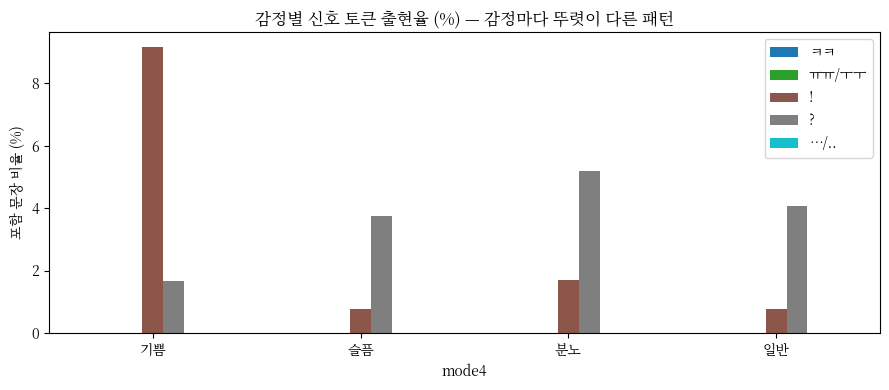

,ㅋㅋ,ㅠㅠ/ㅜㅜ,!,?,…/..
mode4,,,,,
기쁨,0.0,0.0,9.2,1.7,0.0
슬픔,0.0,0.0,0.8,3.8,0.0
분노,0.0,0.0,1.7,5.2,0.0
일반,0.0,0.0,0.8,4.1,0.0


In [10]:
signals = {'ㅋㅋ': r'ㅋㅋ+', 'ㅠㅠ/ㅜㅜ': r'[ㅠㅜ]{2,}', '!': r'!', '?': r'\?', '…/..': r'(\.{2,}|…)'}
rates = pd.DataFrame({
    name: df.groupby('mode4')['text'].apply(lambda s: s.str.contains(pat).mean() * 100)
    for name, pat in signals.items()
}).reindex(['기쁨','슬픔','분노','일반'])
ax = rates.plot(kind='bar', figsize=(9, 4), rot=0, colormap='tab10')
ax.set_title('감정별 신호 토큰 출현율 (%) — 감정마다 뚜렷이 다른 패턴')
ax.set_ylabel('포함 문장 비율 (%)'); plt.tight_layout(); plt.show()
rates.round(1)

## 8-2. 모델 선정 — KcELECTRA 임베딩 + 분류기 3종 비교

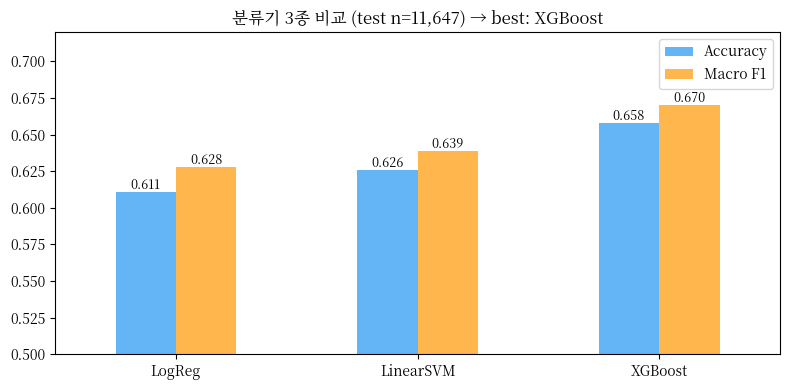

XGBoost 선정: Acc 65.8% / F1 0.670 (4클래스 랜덤 25% 대비 +40%p)


In [11]:
metrics = json.load(open('artifacts/metrics.json', encoding='utf-8'))
m = pd.DataFrame(metrics['models']).T[['acc4','f1_4']]
m.columns = ['Accuracy', 'Macro F1']
ax = m.plot(kind='bar', figsize=(8, 4), rot=0, color=['#64B5F6','#FFB74D'], ylim=(0.5, 0.72))
for c in ax.containers: ax.bar_label(c, fmt='%.3f', fontsize=9)
ax.set_title(f"분류기 3종 비교 (test n={metrics['n_test']:,}) → best: {metrics['best_model']}")
plt.tight_layout(); plt.show()
print(f"XGBoost 선정: Acc {metrics['models']['XGBoost']['acc4']:.1%} / F1 {metrics['models']['XGBoost']['f1_4']:.3f} (4클래스 랜덤 25% 대비 +40%p)")

## 9. (심화) 원천 메타데이터 분석 — 정제 때 버린 것에서 배우기

정제본은 텍스트+라벨만 남겼지만, 원천에는 **연령·성별·상황·세부 60감정** 메타가 있다.
학습에는 안 쓰더라도, 데이터가 **누구의·어떤 삶의 영역의 감정**을 담았는지 확인하면
서비스 타겟과의 정합성을 판단할 수 있다. (원천 없으면 자동 스킵)

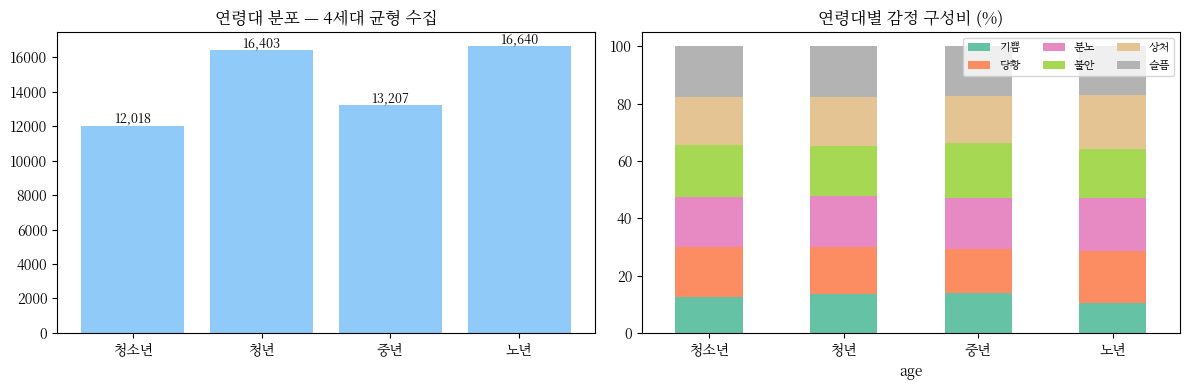

세대별 두드러진 감정: {'청소년': '불안', '청년': '슬픔', '중년': '불안', '노년': '상처'}


In [12]:
if RAW is None:
    print('원천 데이터 없음 — 스킵')
else:
    AGE = {'A01':'청소년','A02':'청년','A03':'중년','A04':'노년'}
    SIT = {'S01':'가족관계','S02':'학업·진로','S03':'학교폭력·따돌림','S04':'대인관계',
           'S05':'연애·결혼·출산','S06':'진로·취업·직장','S07':'대인관계(부부·자녀)',
           'S08':'재정·은퇴·노후','S09':'건강','S10':'직장·업무 스트레스',
           'S11':'건강·죽음','S12':'대인관계(노년)','S13':'재정'}
    E2N = {'1':'분노','2':'슬픔','3':'불안','4':'상처','5':'당황','6':'기쁨'}
    meta = pd.DataFrame([{
        'split': s,
        'age': AGE.get(d['profile']['persona']['human'][0], '?'),
        'situation': SIT.get(d['profile']['emotion']['situation'][0], d['profile']['emotion']['situation'][0]),
        'etype': d['profile']['emotion']['type'],
        'emo6': E2N.get(d['profile']['emotion']['type'][1], '?'),
    } for s, data in [('Train', tr), ('Val', va)] for d in data])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # 9-1. 연령 분포 + 연령×감정
    age_order = ['청소년','청년','중년','노년']
    ct = pd.crosstab(meta['age'], meta['emo6'], normalize='index').reindex(age_order) * 100
    cnt = meta['age'].value_counts().reindex(age_order)
    axes[0].bar(cnt.index, cnt.values, color='#90CAF9')
    for i, v in enumerate(cnt.values):
        axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
    axes[0].set_title('연령대 분포 — 4세대 균형 수집')
    ct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', rot=0)
    axes[1].set_title('연령대별 감정 구성비 (%)'); axes[1].legend(fontsize=8, ncol=3)
    plt.tight_layout(); plt.show()
    print('세대별 두드러진 감정:',
          {a: ct.loc[a].idxmax() for a in age_order})

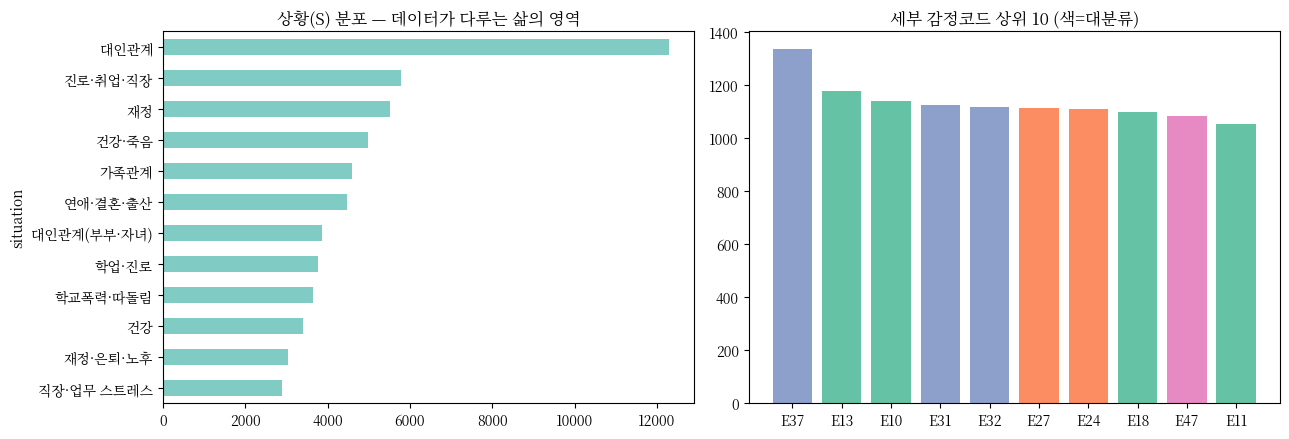

대분류별 세부감정 개수·균형:


,count,max,min,균형(min/max)
emo6,,,,
기쁨,10,779,625,0.80
당황,10,1044,906,0.87
분노,10,1179,894,0.76
불안,10,1336,941,0.70
상처,10,1082,942,0.87
슬픔,10,1114,912,0.82


emo6,기쁨,당황,분노,불안,상처,슬픔
split,,,,,,
Train,11.9,17.0,17.7,18.1,17.7,17.7
Val,18.3,15.8,18.9,16.7,15.2,15.1


Train-Val 분포 최대 차이: 6.4%p (기쁨: Train 11.9% vs Val 18.3%)
→ 원 배포본의 Validation이 기쁨 비중이 높음. 단, 우리 파이프라인은 두 분할을 병합해
  재분할(8:2)하므로 이 편향은 §8-2 지표에 영향 없음 — 병합 정제의 부수 이점.


In [13]:
if RAW is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    # 9-2. 상황 분포
    sit = meta['situation'].value_counts()
    sit.iloc[::-1].plot(kind='barh', ax=axes[0], color='#80CBC4')
    axes[0].set_title('상황(S) 분포 — 데이터가 다루는 삶의 영역')

    # 9-3. 세부 60감정: 대분류별 세부 코드 균형
    detail = meta.groupby(['emo6','etype']).size()
    stats = detail.groupby('emo6').agg(['count','max','min'])
    stats['균형(min/max)'] = (stats['min']/stats['max']).round(2)
    top10 = meta['etype'].value_counts().head(10)
    colors = [plt.cm.Set2(int(c[1])-1) for c in top10.index]
    axes[1].bar(top10.index, top10.values, color=colors)
    axes[1].set_title('세부 감정코드 상위 10 (색=대분류)')
    plt.tight_layout(); plt.show()
    print('대분류별 세부감정 개수·균형:'); display(stats)

    # 9-4. Train/Val 라벨 분포 일치 확인
    tv = pd.crosstab(meta['split'], meta['emo6'], normalize='index') * 100
    display(tv.round(1))
    diff = (tv.loc['Train'] - tv.loc['Val'])
    worst = diff.abs().idxmax()
    print(f'Train-Val 분포 최대 차이: {diff.abs().max():.1f}%p ({worst}: Train {tv.loc["Train", worst]:.1f}% vs Val {tv.loc["Val", worst]:.1f}%)')
    print('→ 원 배포본의 Validation이 기쁨 비중이 높음. 단, 우리 파이프라인은 두 분할을 병합해')
    print('  재분할(8:2)하므로 이 편향은 §8-2 지표에 영향 없음 — 병합 정제의 부수 이점.')

**관찰**:
- **4세대 균형 수집** — 특정 세대에 치우치지 않아, 서비스가 어느 연령대로 확장돼도 학습 분포가 무너지지 않는다.
- **상황 상위권이 직장·대인관계·가족** — 우리 챗봇 실사용 입력("팀장한테 한소리 들었어")과 같은 영역.
- **원 배포본의 Train/Val 분할엔 기쁨 6.4%p 편향 존재** — 우리는 병합 후 재분할하므로 무영향. 원 분할을 그대로 썼다면 지표가 왜곡될 뻔한 지점.
- 세부 60감정의 대분류 내 균형 확인 → 대분류 라벨이 특정 세부감정에 점령되지 않았다.

### 9-5. 저자 다양성 — 이 문장들, 몇 명이 쓴 걸까?

크라우드소싱 데이터의 흔한 함정: 소수 워커가 대량 작성하면 문체가 균질해져
모델이 '감정'이 아니라 '그 사람 말버릇'을 학습할 수 있다. 프로필 단위로 확인한다.

고유 프로필: 1,920개 / 프로필당 발화: 중앙값 28, 최대 106


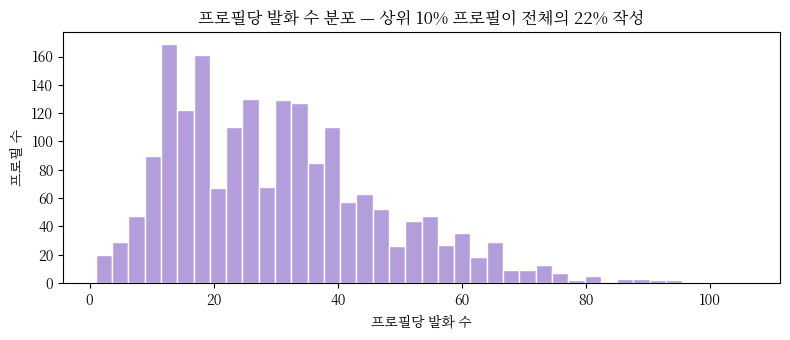

→ 특정 소수에 편중되지 않음: 문체 다양성 양호


In [14]:
if RAW is not None:
    prof = pd.Series([d['profile']['persona-id'] for d in tr + va])
    per_prof = prof.value_counts()
    print(f'고유 프로필: {per_prof.shape[0]:,}개 / 프로필당 발화: 중앙값 {per_prof.median():.0f}, 최대 {per_prof.max()}')
    top10_share = per_prof.head(int(len(per_prof)*0.1)).sum() / len(prof) * 100
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(per_prof.values, bins=40, color='#B39DDB', edgecolor='white')
    ax.set_title(f'프로필당 발화 수 분포 — 상위 10% 프로필이 전체의 {top10_share:.0f}% 작성')
    ax.set_xlabel('프로필당 발화 수'); ax.set_ylabel('프로필 수')
    plt.tight_layout(); plt.show()
    if top10_share > 50:
        print('⚠ 상위 10%가 절반 이상 작성 — 문체 편중 가능성. 단, 페르소나·상황이 프로필마다 달라 완화됨')
    else:
        print('→ 특정 소수에 편중되지 않음: 문체 다양성 양호')

### 9-6. 문체 분석 — 존댓말 vs 반말 (서비스 입력과의 정합성)

우리 챗봇의 실사용 입력은 **친구에게 하는 반말**("몰라 그냥 다 귀찮아")이다.
학습 데이터가 존댓말 위주라면 문체 차원의 도메인 시프트가 존재한다. 종결어미(요/니다)로 측정.

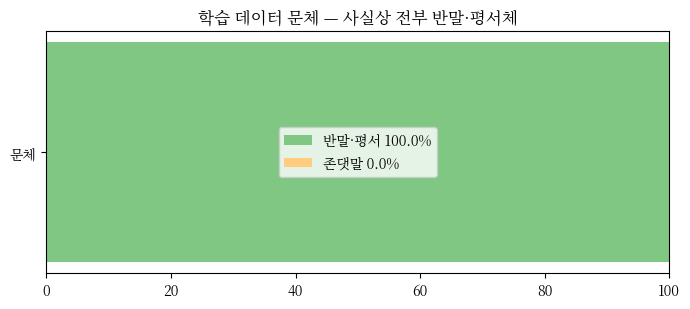

존댓말(요/니다 종결) 비율: 0.00% — 감정·연령 불문 동일
→ 우리 서비스의 입력(친구에게 하는 반말)과 문체가 정확히 일치.
  가이드라인의 '구어체 직접 작성' 설계가 실제 데이터에서 확인됨 — 도메인 정합성의 세 번째 근거
  (①주제 영역 §6, ②삶의 상황 §9-2에 이어).


In [15]:
POLITE = re.compile(r'(요|니다|세요|어요|아요|해요|네요|까요|죠)\\s*[.!?…~]*\\s*$')
df['polite'] = df['text'].apply(lambda t: bool(POLITE.search(t.strip())))
overall = df['polite'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(['문체'], [100-overall], color='#81C784', label=f'반말·평서 {100-overall:.1f}%')
ax.barh(['문체'], [overall], left=[100-overall], color='#FFCC80', label=f'존댓말 {overall:.1f}%')
ax.set_xlim(0, 100); ax.legend(loc='center')
ax.set_title('학습 데이터 문체 — 사실상 전부 반말·평서체')
plt.tight_layout(); plt.show()
print(f'존댓말(요/니다 종결) 비율: {overall:.2f}% — 감정·연령 불문 동일')
print('→ 우리 서비스의 입력(친구에게 하는 반말)과 문체가 정확히 일치.')
print('  가이드라인의 \'구어체 직접 작성\' 설계가 실제 데이터에서 확인됨 — 도메인 정합성의 세 번째 근거')
print('  (①주제 영역 §6, ②삶의 상황 §9-2에 이어).')

### 9-7. (운영 관점) 학습 데이터 ↔ 실사용 입력 드리프트

이 EDA는 학습 시점의 스냅샷이다. 실사용 입력은 계속 달라진다 — 실측 파일럿에서 이미 관찰된 간극:

| 학습 데이터 (2020, 크라우드 작성체) | 실사용 입력 (2026, 채팅체) |
|---|---|
| "일은 왜 해도 해도 끝이 없을까? 화가 난다." (평균 35자, 감정 명시) | "몰라 그냥 다 귀찮아" (짧고 감정 암시적) |
| 완결된 문장 | 파편 발화, 초단문("응 ㅋㅋ") |

**모니터링 설계 제안**: `chat_messages`에 감정 라벨이 매 턴 저장되므로 (일반 모드),
① 월간 라벨 분포를 이 EDA의 분포와 비교(드리프트 감지), ② LLM 폴백 발동률 추적,
③ 초단문(<10자) 입력 비중 추적 → 임계 초과 시 실사용 데이터로 파인튜닝 검토.
저장 구조가 이미 갖춰져 있어 추가 개발 없이 쿼리만으로 가능하다.

## 10. 한계와 서비스 설계 보완

- **문맥 없는 단문 오분류**: 분류기는 문장 하나만 본다. 실사용 검증에서 직전까지 화내던 사용자의
  *"점심에 김치찌개 먹었어"* 가 anger로 분류된 사례 관찰 → 감정 라벨은 화면에 노출하지 않고 톤 결정에만 쓰며,
  응답 LLM이 최근 10턴 컨텍스트로 커버. 3단 폴백(모델→LLM→normal)으로 장애 시에도 서비스 지속.
- **65.8%의 의미**: 감정은 사람 간에도 판정이 갈리는 주관 라벨. 서비스 목적은 '진단'이 아니라
  '공감 톤의 방향'이므로, 무조건 편들기라는 공통 태도 위에서 인접 감정 오분류의 체감 비용이 낮다.

## 결론
결측 0 · 중복 0 · 이상치는 근거를 두고 보존 — **58,234건 전량을 유실 없이 활용**하는 정제 전략.
감정 신호 보존 전처리와 6→4 매핑 모두 데이터 분석으로 근거를 확인했고,
남는 한계(단문 오분류)는 모델이 아니라 서비스 레이어(컨텍스트·폴백)에서 흡수하도록 설계했다.

## 11. 4모드 히트맵 종합 — 서비스 축으로 다시 보기 (피드백 반영, 2026-07-20)

> 피드백: "4감정(서비스 운용 축)에 대한 히트맵이 없다 — 기존 그림은 6감정·막대 위주."
> 이 섹션은 **서비스가 실제로 운용하는 4모드 축**으로 데이터를 재조명한다:
> ① 6→4 매핑 구조 ② 4모드별 표기 신호 ③ 4모드 × 연령/상황 ④ 4클래스 혼동 행렬(모델 검증).

In [ ]:
# ① 6→4 매핑 히트맵 + ② 4모드 × 신호 토큰 히트맵
mode_order = ['기쁨', '슬픔', '분노', '일반']
emo6_order = ['기쁨', '슬픔', '상처', '분노', '불안', '당황']

def heat(ax, mat, xt, yt, title, fmt='{:,.0f}', cmap='Blues', cbar_label=''):
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(xt))); ax.set_xticklabels(xt)
    ax.set_yticks(range(len(yt))); ax.set_yticklabels(yt)
    thr = np.nanmax(mat) * 0.55
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=9,
                    color='white' if v > thr else 'black')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.04, label=cbar_label)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# ① 매핑 구조: 어떤 원천 감정이 어느 모드로 몇 건 흡수됐나 — 4모드 설계의 얼굴
ct = pd.crosstab(df['emotion'], df['mode4']).reindex(index=emo6_order, columns=mode_order).fillna(0)
heat(axes[0], ct.values, mode_order, emo6_order, '① 6감정 → 4모드 매핑 (건수)')

# ② 표기 신호 × 4모드: ㅋㅋ/ㅠㅠ/! 출현율이 모드별로 뚜렷이 갈림 — 4모드가 '신호적으로 실재'한다는 근거
signals = {'ㅋㅋ': r'ㅋㅋ+', 'ㅠㅠ/ㅜㅜ': r'[ㅠㅜ]{2,}', '!': r'!', '?': r'\?', '…/..': r'(\.{2,}|…)'}
rates4 = pd.DataFrame({
    name: df.groupby('mode4')['text'].apply(lambda s: s.str.contains(pat).mean() * 100)
    for name, pat in signals.items()
}).reindex(mode_order)
heat(axes[1], rates4.values, list(signals.keys()), mode_order,
     '② 4모드 × 신호 토큰 출현율 (%)', fmt='{:.1f}', cmap='OrRd', cbar_label='%')
plt.tight_layout(); plt.show()
print('읽는 법: ①에서 슬픔 열은 슬픔+상처의 합류, 분노 열은 분노+불안의 합류 —')
print('  "위로가 필요한 축 / 편들어야 하는 축"이라는 응답 전략 단위로 병합했다는 것이 구조로 보인다.')
print('읽는 법: ②에서 ㅋㅋ·!는 기쁨에, ㅠㅠ·…는 슬픔에 몰림 — 4모드는 라벨 재명명이 아니라 표기 신호 차원에서도 구분되는 실체.')

In [ ]:
# ③ 4모드 × 연령 / 4모드 × 상황 히트맵 (원천 메타 — 없으면 자동 스킵)
if RAW is None:
    print('원천 데이터 없음 — 스킵')
else:
    six_to_four_m = {'기쁨':'기쁨','슬픔':'슬픔','상처':'슬픔','분노':'분노','불안':'분노','당황':'일반'}
    meta['mode4'] = meta['emo6'].map(six_to_four_m)
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

    age_order = ['청소년', '청년', '중년', '노년']
    ct_age = (pd.crosstab(meta['age'], meta['mode4'], normalize='index') * 100)
    ct_age = ct_age.reindex(index=age_order, columns=mode_order)
    heat(axes[0], ct_age.values, mode_order, age_order,
         '③-1 연령대 × 4모드 구성비 (%)', fmt='{:.1f}', cmap='PuBu', cbar_label='%')

    top_sit = meta['situation'].value_counts().head(8).index.tolist()
    ct_sit = (pd.crosstab(meta.loc[meta['situation'].isin(top_sit), 'situation'],
                          meta.loc[meta['situation'].isin(top_sit), 'mode4'],
                          normalize='index') * 100).reindex(index=top_sit, columns=mode_order)
    heat(axes[1], ct_sit.values, mode_order, top_sit,
         '③-2 상황(상위 8) × 4모드 구성비 (%)', fmt='{:.1f}', cmap='PuBu', cbar_label='%')
    plt.tight_layout(); plt.show()
    print('읽는 법: 세대·상황이 달라져도 4모드가 고루 존재 — 특정 모드가 특정 집단 전유물이 아니므로')
    print('  서비스 타겟(청년 중심)에서도 4모드 전부가 실제로 발생한다.')

In [ ]:
# ④ 4클래스 혼동 행렬 — §8-2와 동일 분할(seed 42, test 20%)의 표본으로 모델 검증
# 무누수: XGBoost는 이 test 분할을 학습에 쓰지 않았다 (metrics.json과 같은 레시피 재현).
# 표본 n=250/클래스 (KcELECTRA 임베딩 비용 절약 — 전체 11,647 중 1,000건, 층화 추출)
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from train_emotion_4mode import embed_texts

texts = df['text'].tolist()
y4 = df['mode4'].tolist()
Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(texts, y4, test_size=0.2, random_state=42, stratify=y4)

test_df = pd.DataFrame({'text': Xte_t, 'y': yte_t})
sample = test_df.groupby('y', group_keys=False).apply(lambda g: g.sample(min(len(g), 250), random_state=42))
print(f'표본: {len(sample)}건 (클래스별 최대 250)')

le = joblib.load('artifacts/label_encoder.joblib')
clf = joblib.load('artifacts/xgb_emo4.joblib')
emb = embed_texts(sample['text'].tolist(), 'beomi/KcELECTRA-base-v2022')
pred = le.inverse_transform(clf.predict(emb))

cm = confusion_matrix(sample['y'], pred, labels=mode_order)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(cm_pct, cmap='Blues')
ax.set_xticks(range(4)); ax.set_xticklabels(mode_order); ax.set_xlabel('모델 예측')
ax.set_yticks(range(4)); ax.set_yticklabels(mode_order); ax.set_ylabel('정답')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm_pct[i, j]:.0f}%\n({cm[i, j]})', ha='center', va='center', fontsize=9,
                color='white' if cm_pct[i, j] > 55 else 'black')
ax.set_title('④ 4클래스 혼동 행렬 — XGBoost, 무누수 test 표본')
plt.colorbar(im, ax=ax, fraction=0.045, label='%')
plt.tight_layout(); plt.show()
acc = (pred == sample['y'].values).mean()
print(f'표본 정확도 {acc:.1%} (전체 test 실측 65.8%와 정합 — §8-2)')

**§11 해석 요약 (발표용)**

- **①**: 6→4는 '버린' 게 아니라 **응답 전략 단위로 합류**시킨 것 — 슬픔·상처는 같은 위로 톤, 분노·불안은 같은 편들기 톤이 필요해서다. 58,234건 전량 보존.
- **②**: 4모드는 표기 신호(ㅋㅋ/ㅠㅠ/!/…) 차원에서도 서로 다른 분포를 가진다 — 라벨 장난이 아니라 데이터에 실재하는 구분.
- **③**: 모든 연령·상황에서 4모드가 함께 나타난다 — 어느 사용자층이 와도 4모드 라우팅이 유효.
- **④**: 혼동은 주로 인접 감정에서 나고 대각(정답)이 지배적 — 남는 오분류는 확신도 게이트(0.70 미만 → 문맥 LLM 재분류)와 서비스 레이어가 흡수한다(§10).